# 🗣️ Pivot Narrator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/pivot-narrator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/pivot-narrator/demo.ipynb)

**Nobody reads the pivot table.**

A crosstab is a wall of numbers. The three facts a reader actually needs - what dominates, what
moved, and where the **interaction** is - are all in there, and none of them are legible.

This notebook builds the narrator that writes the paragraph. Deterministically: **no LLM**. Every
sentence is arithmetic with a threshold, so the same pivot always produces the same narration and
every claim traces back to a cell. That matters more than it sounds - a summary you can't audit
is worse than no summary.

### What this notebook covers
1. The pivot nobody reads
2. The independence model: what a cell *should* be
3. Lift - and why the interaction is the actual insight
4. The two guards that stop the narrator being a noise generator
5. Period comparison, and why growth-from-zero is `None` not `inf`
6. The narration, assembled
7. Chart: lift heatmap + movers
8. Try your own pivot

## Step 1 - The pivot nobody reads

Revenue by region × product. The sample is built so the row and column totals are
**multiplicative** - i.e. genuinely independent - *except* for one planted interaction and one
brand-new cell. If the narrator works, it should find exactly those two things.

In [1]:
from __future__ import annotations

from typing import Tuple

import numpy as np
import pandas as pd

RANDOM_SEED = 42
pd.set_option("display.width", 200)


def sample_pivots() -> Tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(RANDOM_SEED)
    regions = ["Singapore", "Malaysia", "Indonesia", "Thailand", "Vietnam"]
    products = ["Core", "Pro", "Enterprise", "Add-ons"]
    # outer product => rows and columns are independent by construction
    base = np.outer(np.array([0.40, 0.22, 0.20, 0.11, 0.07]),
                    np.array([0.45, 0.28, 0.19, 0.08])) * 2_400_000
    prev = pd.DataFrame((base * rng.normal(1.00, 0.04, base.shape)).round(2),
                        index=regions, columns=products)
    cur = pd.DataFrame((base * rng.normal(1.06, 0.05, base.shape)).round(2),
                       index=regions, columns=products)
    # planted interaction: Indonesia over-indexes hard on Enterprise, and grew
    prev.loc["Indonesia", "Enterprise"] *= 2.1
    cur.loc["Indonesia", "Enterprise"] *= 3.0
    # a cell that did not exist last quarter
    prev.loc["Vietnam", "Enterprise"] = 0.0
    cur.loc["Vietnam", "Enterprise"] = 61_500.0
    for d in (prev, cur):
        d.index.name, d.columns.name = "region", "product"
    return cur.round(2), prev.round(2)


cur, prev = sample_pivots()
print(cur.to_string())
print("\nrow totals:")
print(cur.sum(axis=1).to_string())
print("\ncol totals:")
print(cur.sum(axis=0).to_string())

product         Core        Pro  Enterprise   Add-ons
region                                               
Singapore  453926.97  275776.31   204493.58  80814.61
Malaysia   246767.47  154107.43   109009.26  45546.22
Indonesia  233417.51  145359.12   319313.73  39923.68
Thailand   122885.28   75347.50    54714.48  23579.39
Vietnam     79705.28   47886.35    61500.00  14683.60

row totals:
region
Singapore    1015011.47
Malaysia      555430.38
Indonesia     738014.04
Thailand      276526.65
Vietnam       203775.23

col totals:
product
Core          1136702.51
Pro            698476.71
Enterprise     749031.05
Add-ons        204547.50


Stare at that for a moment before scrolling. Singapore is the biggest region and Core is the
biggest product - both obvious from the margins. Now: **which cell is anomalous?**

Most readers can't answer that from the grid, because the anomaly isn't the largest number. It's
the number that's largest *relative to what its row and column sizes predict* - and that
comparison is not something eyes do.

## Step 2 - The independence model

If region and product were independent, each cell would be
`row_total × col_total / grand_total`. That's the same expectation a chi-square test uses. It is
the honest baseline for "what did I already know from the margins?"

In [2]:
def expected_matrix(pivot: pd.DataFrame) -> pd.DataFrame:
    row_tot, col_tot = pivot.sum(axis=1), pivot.sum(axis=0)
    grand = float(pivot.to_numpy().sum())
    if grand == 0:
        return pd.DataFrame(np.zeros(pivot.shape), index=pivot.index, columns=pivot.columns)
    return pd.DataFrame(np.outer(row_tot.to_numpy(), col_tot.to_numpy()) / grand,
                        index=pivot.index, columns=pivot.columns)


def lift_matrix(pivot: pd.DataFrame) -> pd.DataFrame:
    exp = expected_matrix(pivot)
    with np.errstate(divide="ignore", invalid="ignore"):
        return (pivot - exp) / exp.replace(0, np.nan)


print("EXPECTED (if region and product were independent):")
print(expected_matrix(cur).round(0).to_string())
print("\nLIFT % (actual vs expected):")
print((lift_matrix(cur) * 100).round(1).to_string())

EXPECTED (if region and product were independent):
product        Core       Pro  Enterprise  Add-ons
region                                            
Singapore  413720.0  254221.0    272621.0  74448.0
Malaysia   226394.0  139114.0    149183.0  40739.0
Indonesia  300816.0  184844.0    198223.0  54131.0
Thailand   112713.0   69259.0     74272.0  20282.0
Vietnam     83059.0   51038.0     54732.0  14946.0

LIFT % (actual vs expected):
product    Core   Pro  Enterprise  Add-ons
region                                    
Singapore   9.7   8.5       -25.0      8.6
Malaysia    9.0  10.8       -26.9     11.8
Indonesia -22.4 -21.4        61.1    -26.2
Thailand    9.0   8.8       -26.3     16.3
Vietnam    -4.0  -6.2        12.4     -1.8


Now it's obvious. **Indonesia × Enterprise is +61%** against expectation while every other cell
sits within roughly ±27%. That single cell is the story, and it is *not* the biggest number in
the table - Singapore × Core is nearly 1.5× larger and completely unremarkable, because
Singapore is big and Core is big.

Note the shape of the rest of the lift matrix too: `Enterprise` is negative for every *other*
region. That is the arithmetic consequence of Indonesia absorbing Enterprise share - the margin
model has to balance. Worth knowing so you don't report five findings when there is one.

## Step 3 - Two guards, both necessary

Ranking cells by absolute lift alone makes a noise generator. A cell holding 0.1% of the total
can post a 500% lift from a rounding wobble and would lead the narration.

So a cell must clear **both** a lift threshold (is the interaction real?) **and** a share floor
(does it matter?). Here's what dropping the second guard does:

In [3]:
LIFT_THRESHOLD = 0.25
MIN_CELL_SHARE = 0.01


def notable_cells(pivot, lift_threshold=LIFT_THRESHOLD, min_share=MIN_CELL_SHARE, top=4):
    exp, lift = expected_matrix(pivot), lift_matrix(pivot)
    grand = float(pivot.to_numpy().sum())
    rows = []
    for r in pivot.index:
        for c in pivot.columns:
            actual, e = float(pivot.loc[r, c]), float(exp.loc[r, c])
            lv = 0.0 if pd.isna(lift.loc[r, c]) else float(lift.loc[r, c])
            share = actual / grand if grand else 0.0
            if abs(lv) >= lift_threshold and share >= min_share:
                rows.append({"row": r, "column": c, "actual": round(actual, 2),
                             "expected": round(e, 2), "lift": round(lv, 4),
                             "share_of_total": round(share, 4),
                             "direction": "over" if lv > 0 else "under"})
    if not rows:
        return pd.DataFrame(columns=["row", "column", "actual", "expected", "lift",
                                     "share_of_total", "direction"])
    out = pd.DataFrame(rows)
    out["abs_lift"] = out["lift"].abs()
    return out.sort_values("abs_lift", ascending=False).drop(columns="abs_lift").head(top)


# Add a deliberately tiny, deliberately loud cell.
noisy = cur.copy()
noisy.loc["Vietnam", "Add-ons"] = noisy.loc["Vietnam", "Add-ons"] * 0.08 + 900

print("WITH the share floor (1% of total):")
print(notable_cells(noisy, min_share=0.01, top=5).to_string(index=False))
print("\nWITHOUT it (share floor = 0):")
print(notable_cells(noisy, min_share=0.0, top=5).to_string(index=False))

WITH the share floor (1% of total):
      row     column    actual  expected    lift  share_of_total direction
Indonesia Enterprise 319313.73 199123.12  0.6036          0.1150      over
 Malaysia Enterprise 109009.26 149860.34 -0.2726          0.0393     under
 Thailand Enterprise  54714.48  74609.49 -0.2667          0.0197     under
Singapore Enterprise 204493.58 273859.63 -0.2533          0.0737     under

WITHOUT it (share floor = 0):
      row     column    actual  expected    lift  share_of_total direction
  Vietnam    Add-ons   2074.69  13216.94 -0.8430          0.0007     under
Indonesia Enterprise 319313.73 199123.12  0.6036          0.1150      over
 Malaysia Enterprise 109009.26 149860.34 -0.2726          0.0393     under
 Thailand Enterprise  54714.48  74609.49 -0.2667          0.0197     under
Singapore Enterprise 204493.58 273859.63 -0.2533          0.0737     under


Without the floor, a cell worth **0.03%** of revenue outranks the real finding purely because a
small number moved. With it, the narration stays about things worth a meeting.

## Step 4 - Period comparison, and the divide-by-zero everyone ships

`Vietnam × Enterprise` was 0 last quarter and 61.5k this quarter. A naive `pct_change` emits
`inf`, which then renders as "+inf%" in a slide.

Growth from zero is **undefined, not infinite**. So the code writes `None` (which pandas stores
as `NaN` in a float column - the point is that it is *null*, never `inf`) and sets an explicit
`is_new` flag. That flag, not the ratio, drives the sentence: the narration says "new", which is
also the more useful statement, because a segment *appearing* is a different event from a segment
*growing*. The two pivots are reindexed to the **union** of both periods for the same reason - a
row that disappears should be reported, not silently dropped.

In [4]:
def compare_periods(current, previous, top=3):
    idx = current.index.union(previous.index)
    cols = current.columns.union(previous.columns)
    cur_ = current.reindex(index=idx, columns=cols).fillna(0.0)
    prev_ = previous.reindex(index=idx, columns=cols).fillna(0.0)
    rows = []
    for r in idx:
        for c in cols:
            d = float(cur_.loc[r, c] - prev_.loc[r, c])
            base = float(prev_.loc[r, c])
            if d == 0:
                continue
            rows.append({"row": r, "column": c, "previous": round(base, 2),
                         "current": round(float(cur_.loc[r, c]), 2), "delta": round(d, 2),
                         # undefined, not infinite
                         "pct_change": round(d / base, 4) if base else None,
                         "is_new": base == 0})
    out = pd.DataFrame(rows)
    out["abs_delta"] = out["delta"].abs()
    return out.sort_values("abs_delta", ascending=False).drop(columns="abs_delta").head(top)


movers = compare_periods(cur, prev)
print(movers.to_string(index=False))
print()
naive = (cur.loc["Vietnam", "Enterprise"] - prev.loc["Vietnam", "Enterprise"]) / \
        prev.loc["Vietnam", "Enterprise"] if prev.loc["Vietnam", "Enterprise"] else float("inf")
print(f"naive pct_change for Vietnam x Enterprise: {naive}   <- what lands on the slide")
print(f"ours: pct_change={movers[movers.is_new].iloc[0]['pct_change']}, "
      f"is_new={movers[movers.is_new].iloc[0]['is_new']}   -> narrated as 'new'")

      row     column  previous   current     delta  pct_change  is_new
Indonesia Enterprise 198256.88 319313.73 121056.85      0.6106   False
  Vietnam Enterprise      0.00  61500.00  61500.00         NaN    True
 Malaysia       Core 219057.36 246767.47  27710.11      0.1265   False

naive pct_change for Vietnam x Enterprise: inf   <- what lands on the slide
ours: pct_change=nan, is_new=True   -> narrated as 'new'


## Step 5 - Assemble the narration

Concentration first (is the mean even a valid summary?), then the interaction, then movement.
Order matters: a reader who learns "36% of revenue is one region" reads every later number
differently.

In [5]:
CONCENTRATION_ALERT = 0.5


def _fmt(v, unit=""):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "n/a"
    a = abs(v)
    if a >= 1_000_000:
        return f"{unit}{v / 1_000_000:.2f}M"
    if a >= 1_000:
        return f"{unit}{v / 1_000:.1f}k"
    return f"{unit}{v:,.0f}" if a >= 10 else f"{unit}{v:,.2f}"


def concentration(series):
    s = series.sort_values(ascending=False)
    total = float(s.sum())
    cum = s.cumsum() / total
    return {"top1": s.index[0], "top1_share": float(s.iloc[0] / total),
            "top2": s.index[1] if len(s) > 1 else None,
            "top2_share": float(s.iloc[1] / total) if len(s) > 1 else 0.0,
            "n_for_half": int((cum < 0.5).sum() + 1), "n": len(s)}


def narrate(pivot, metric="value", unit="", previous=None, row_label="row", col_label="column"):
    grand = float(pivot.to_numpy().sum())
    row_tot = pivot.sum(axis=1).sort_values(ascending=False)
    col_tot = pivot.sum(axis=0).sort_values(ascending=False)
    rc, cc = concentration(row_tot), concentration(col_tot)
    paras = []

    p1 = (f"Total {metric} is {_fmt(grand, unit)}. The largest {row_label} is {rc['top1']} at "
          f"{_fmt(row_tot.iloc[0], unit)} ({rc['top1_share']:.0%} of the total)")
    if rc["top2"]:
        p1 += f", followed by {rc['top2']} at {rc['top2_share']:.0%}"
    p1 += (f". Half the total sits in {rc['n_for_half']} of {rc['n']} {row_label}s. "
           f"By {col_label}, {cc['top1']} leads with {cc['top1_share']:.0%}.")
    paras.append(p1)

    if rc["top1_share"] >= CONCENTRATION_ALERT:
        paras.append(f"{rc['top1']} alone is {rc['top1_share']:.0%} of {metric}, so the average "
                     f"across {row_label}s describes almost nothing - read the rows, not the mean.")

    nc = notable_cells(pivot)
    if len(nc):
        bits = [f"{r['row']} x {r['column']} is {abs(r['lift']):.0%} "
                f"{'above' if r['direction'] == 'over' else 'below'} expectation "
                f"({_fmt(r['actual'], unit)} vs {_fmt(r['expected'], unit)})"
                for _, r in nc.iterrows()]
        paras.append("Against what the row and column totals alone predict: "
                     + "; ".join(bits) + ".")
        t = nc.iloc[0]
        paras.append(f"The strongest interaction is {t['row']} x {t['column']}. Neither "
                     f"{t['row']}'s size nor {t['column']}'s size explains it - it is "
                     f"{abs(t['lift']):.0%} "
                     f"{'higher' if t['direction'] == 'over' else 'lower'} than the margins "
                     f"imply, which is the kind of thing a grid of numbers hides in plain sight.")
    else:
        paras.append(f"No cell deviates more than {LIFT_THRESHOLD:.0%} from what its row and "
                     f"column totals predict - the margins tell the whole story.")

    mv = pd.DataFrame()
    if previous is not None:
        pg = float(previous.to_numpy().sum())
        ch = (grand - pg) / pg if pg else None
        paras.append(f"Against the comparison period, {metric} is "
                     f"{'up' if ch and ch > 0 else 'down'} {abs(ch):.1%} "
                     f"({_fmt(pg, unit)} to {_fmt(grand, unit)}).")
        mv = compare_periods(pivot, previous)
        mbits = []
        for _, m in mv.iterrows():
            mbits.append(f"{m['row']} x {m['column']} is new at {_fmt(m['current'], unit)}"
                         if m["is_new"] else
                         f"{m['row']} x {m['column']} moved {_fmt(m['delta'], unit)} "
                         f"({m['pct_change']:+.0%})")
        if mbits:
            paras.append("Biggest movers: " + "; ".join(mbits) + ".")
    return paras, nc, mv


paras, nc, mv = narrate(cur, "revenue", "$", prev, "region", "product")
print(f"revenue: {_fmt(float(cur.to_numpy().sum()), '$')} across "
      f"{cur.shape[0]} regions x {cur.shape[1]} products\n")
for p in paras:
    print(p + "\n")

revenue: $2.79M across 5 regions x 4 products

Total revenue is $2.79M. The largest region is Singapore at $1.02M (36% of the total), followed by Indonesia at 26%. Half the total sits in 2 of 5 regions. By product, Core leads with 41%.

Against what the row and column totals alone predict: Indonesia x Enterprise is 61% above expectation ($319.3k vs $198.2k); Malaysia x Enterprise is 27% below expectation ($109.0k vs $149.2k); Thailand x Enterprise is 26% below expectation ($54.7k vs $74.3k); Indonesia x Add-ons is 26% below expectation ($39.9k vs $54.1k).

The strongest interaction is Indonesia x Enterprise. Neither Indonesia's size nor Enterprise's size explains it - it is 61% higher than the margins imply, which is the kind of thing a grid of numbers hides in plain sight.

Against the comparison period, revenue is up 13.8% ($2.45M to $2.79M).

Biggest movers: Indonesia x Enterprise moved $121.1k (+61%); Vietnam x Enterprise is new at $61.5k; Malaysia x Core moved $27.7k (+13%).



That is the text that should sit under the table. Six sentences, no model call, fully
reproducible - and it names the one cell a reader would never have found.

## Step 6 - The picture

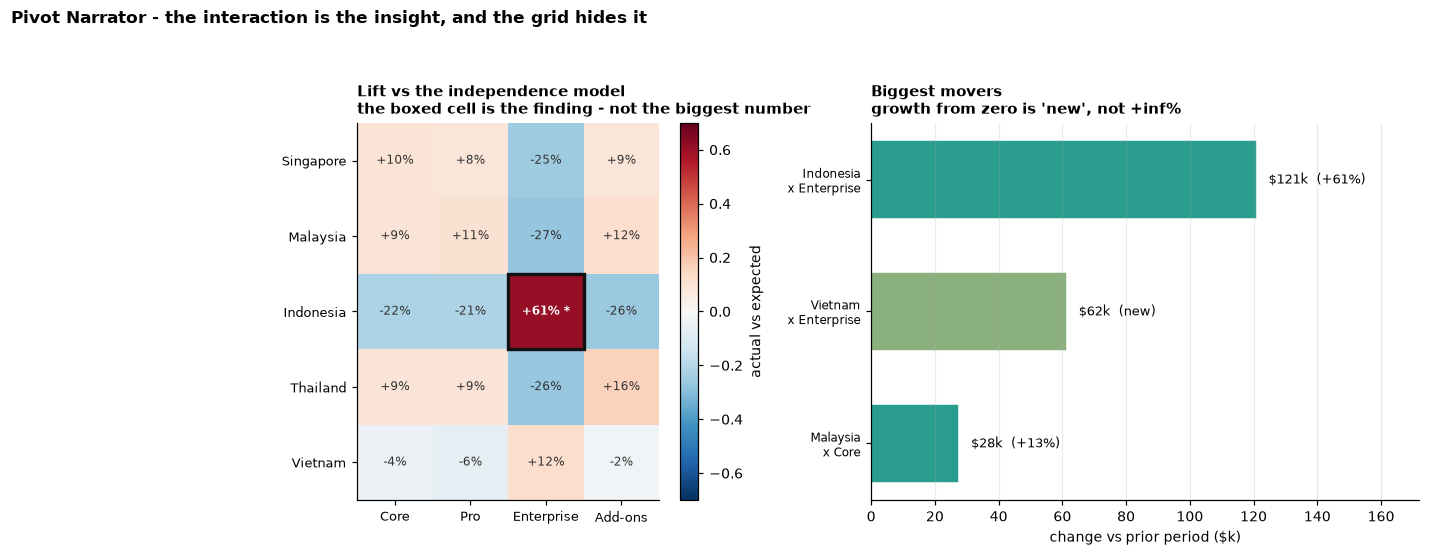

In [6]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False,
                     "axes.spines.top": False, "axes.spines.right": False})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.9),
                               gridspec_kw={"width_ratios": [1.25, 1]})

# --- lift heatmap
lift = lift_matrix(cur)
im = ax1.imshow(lift.to_numpy(), cmap="RdBu_r", vmin=-0.7, vmax=0.7)
ax1.set_xticks(range(len(cur.columns)))
ax1.set_xticklabels(cur.columns, fontsize=8.5)
ax1.set_yticks(range(len(cur.index)))
ax1.set_yticklabels(cur.index, fontsize=8.5)
top = nc.iloc[0]
for i, r in enumerate(cur.index):
    for j, c in enumerate(cur.columns):
        v = lift.loc[r, c]
        star = " *" if (r == top["row"] and c == top["column"]) else ""
        ax1.text(j, i, f"{v:+.0%}{star}", ha="center", va="center", fontsize=8,
                 color="white" if abs(v) > 0.42 else "#333",
                 fontweight="bold" if star else "normal")
        if star:
            ax1.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                        edgecolor="#111", lw=2.2))
ax1.set_title("Lift vs the independence model\nthe boxed cell is the finding - not the "
              "biggest number",
              loc="left", fontweight="bold", fontsize=9.5)
fig.colorbar(im, ax=ax1, fraction=0.035, pad=0.03, label="actual vs expected")

# --- movers
ax2.grid(axis="x", alpha=0.25)
mv_plot = mv.iloc[::-1]
labels = [f"{r['row']}\n x {r['column']}" for _, r in mv_plot.iterrows()]
vals = mv_plot["delta"].to_numpy() / 1000
colors = ["#8ab17d" if r["is_new"] else "#2a9d8f" for _, r in mv_plot.iterrows()]
bars = ax2.barh(labels, vals, color=colors, edgecolor="white", height=0.6)
for b, (_, r) in zip(bars, mv_plot.iterrows()):
    tag = "new" if r["is_new"] else f"{r['pct_change']:+.0%}"
    ax2.text(b.get_width() + max(vals) * 0.03, b.get_y() + b.get_height() / 2,
             f"${r['delta'] / 1000:,.0f}k  ({tag})", va="center", fontsize=8.5)
ax2.set_xlim(0, max(vals) * 1.42)
ax2.set_xlabel("change vs prior period ($k)")
ax2.tick_params(axis="y", labelsize=8)
ax2.set_title("Biggest movers\ngrowth from zero is 'new', not +inf%",
              loc="left", fontweight="bold", fontsize=9.5)

fig.suptitle("Pivot Narrator - the interaction is the insight, and the grid hides it",
             fontsize=11, fontweight="bold", x=0.005, ha="left", y=1.02)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig("pivot_narration.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| What the narrator says | Where it comes from |
|---|---|
| Singapore is 36% of revenue; half the total in 2 of 5 regions | row margins + cumulative share |
| **Indonesia × Enterprise is +61% above expectation** | `actual vs row_total × col_total / grand_total` |
| Enterprise is below expectation everywhere else | the same margin model, balancing |
| Revenue up 13.8% quarter on quarter | grand totals |
| Vietnam × Enterprise is **new** at $61.5k | prior value was 0 → growth undefined, not `inf` |

**The takeaway:** the insight in a crosstab is almost never the biggest number - it's the cell
that deviates most from what its margins already imply. Singapore × Core is the largest value in
this table and says nothing; Indonesia × Enterprise is a third its size and is the entire story.

Three decisions made this useful rather than noisy: compare against the **independence model**,
guard notability with **both** a lift threshold and a share floor, and treat growth from zero as
**undefined** rather than infinite. And keep it deterministic - a summary you can trace to a cell
is auditable in a way a generated one is not.

## Try your own pivot

In [7]:
# --- your own crosstab ---------------------------------------------------
# raw = pd.read_csv("my_data.csv")
# mine = raw.pivot_table(index="region", columns="product", values="revenue",
#                        aggfunc="sum", fill_value=0)
# paras, nc, mv = narrate(mine, metric="revenue", unit="$",
#                         row_label="region", col_label="product")
# for p in paras:
#     print(p, "\n")

# Demo: a pivot with NO interaction, to show the narrator says so plainly.
flat = pd.DataFrame(
    np.outer([0.4, 0.3, 0.2, 0.1], [0.5, 0.3, 0.2]) * 1_000_000,
    index=["North", "South", "East", "West"], columns=["A", "B", "C"],
)
flat.index.name, flat.columns.name = "region", "product"
paras_flat, nc_flat, _ = narrate(flat, "revenue", "$", None, "region", "product")
print("PERFECTLY INDEPENDENT PIVOT:\n")
for p in paras_flat:
    print(p + "\n")
print(f"notable cells found: {len(nc_flat)}  <- correctly reports nothing to see")

PERFECTLY INDEPENDENT PIVOT:

Total revenue is $1.00M. The largest region is North at $400.0k (40% of the total), followed by South at 30%. Half the total sits in 2 of 4 regions. By product, A leads with 50%.

No cell deviates more than 25% from what its row and column totals predict - the margins tell the whole story.

notable cells found: 0  <- correctly reports nothing to see


---

**Day 130** of the daily FDE build - **Analytics Engineering & BI** line.

Companions: **Day 107** [`kpi-tree`](../kpi-tree) (decompose the driver this surfaces),
**Day 121** [`metric-diff`](../metric-diff) (is the movement significant?),
**Day 120** [`crosstab-chi2`](../../data-science-cookbook/crosstab-chi2) (test the interaction
formally - same expectation model).

```bash
pip install -r requirements.txt
streamlit run app.py     # pivot + narration side by side, upload your own
python narrate.py        # CLI narration
```

← [Back to the portfolio](https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/pivot-narrator)